**Import necessary libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import binomtest, chi2_contingency, pointbiserialr

**Load data**

In [ ]:
df = pd.read_csv('honey_encryption_survey_data.csv')

In [ ]:
df['correct_int'] = df['correct_password_chosen'].astype(int)

In [ ]:
confidence_order = ['Not confident', 'Somewhat confident', 'Very confident']

In [ ]:
english_order    = ['Beginner', 'Intermediate', 'Advanced']

In [ ]:
df['confidence_ord'] = pd.Categorical(df['confidence'], categories=confidence_order, ordered=True).codes

In [ ]:
df['english_ord']    = pd.Categorical(df['english_level'], categories=english_order, ordered=True).codes

In [ ]:
df.shape

(33, 14)

In [ ]:
df.head()

,_id,age_range,gender,education,english_level,english_exam,selected_password,correct_password_chosen,sentence_shown,confidence,timestamp,correct_int,confidence_ord,english_ord
0,69a8d11461aaad52d208bacd,16 - 25,Male,Tertiary education,Advanced,IELTS/TOEFL/Duolingo,letmein1!,False,Her husband devoured the last slice of cake in...,Somewhat confident,2026-03-05T00:40:52.833823,0,1,2
1,69a95e8161aaad52d208bace,26 - 35,Male,Postgraduate education,Advanced,JAMB/WAEC,admin@123,False,The professor burst into laughter at the unexp...,Very confident,2026-03-05T10:44:17.816319,0,2,2
2,69a9624361aaad52d208bacf,16 - 25,Male,Tertiary education,Intermediate,JAMB/WAEC,sunshine1,False,My father walked with precision.,Somewhat confident,2026-03-05T11:00:19.637828,0,1,1
3,69a96aa461aaad52d208bad0,26 - 35,Male,Tertiary education,Intermediate,JAMB/WAEC,Iam123@,True,God does not play dice with the universe.,Very confident,2026-03-05T11:36:04.552971,1,2,1
4,69a98e4761aaad52d208bad1,16 - 25,Male,Tertiary education,Advanced,JAMB/WAEC,123456789,False,His best friend offered words of comfort to a ...,Somewhat confident,2026-03-05T14:08:07.948003,0,1,2


In [ ]:
for col in ['gender', 'age_range', 'education', 'english_level', 'confidence']:
    print(f"\n{col.upper()}")
    print(df[col].value_counts())


GENDER
gender
Male                 23
Female                9
Prefer not to say     1
Name: count, dtype: int64

AGE_RANGE
age_range
16 - 25    24
26 - 35     7
Over 65     1
36 - 45     1
Name: count, dtype: int64

EDUCATION
education
Tertiary education            19
Postgraduate education         7
Senior secondary education     5
Basic education                1
No formal education            1
Name: count, dtype: int64

ENGLISH_LEVEL
english_level
Intermediate    19
Advanced        12
Beginner         2
Name: count, dtype: int64

CONFIDENCE
confidence
Somewhat confident    15
Very confident        15
Not confident          3
Name: count, dtype: int64


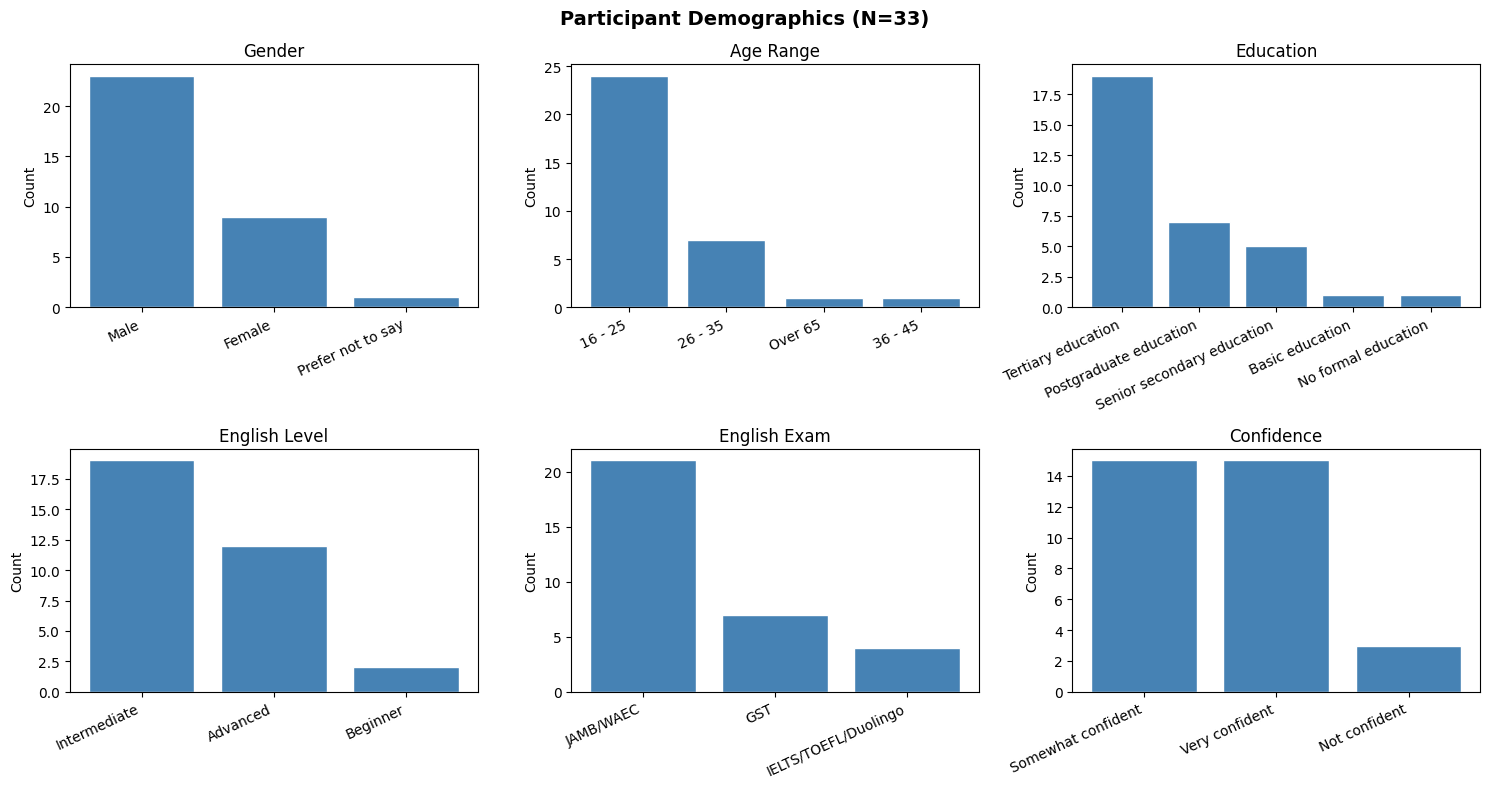

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Participant Demographics (N=33)', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), ['gender', 'age_range', 'education', 'english_level', 'english_exam', 'confidence']):
    vc = df[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=25, ha='right')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('demographics.png', bbox_inches='tight')
plt.show()

In [ ]:
N_OPTIONS = 5
CHANCE_LEVEL = 1 / N_OPTIONS

n_total   = len(df)
n_correct = df['correct_int'].sum()
obs_rate  = n_correct / n_total

result = binomtest(k=n_correct, n=n_total, p=CHANCE_LEVEL, alternative='greater')
ci     = result.proportion_ci(confidence_level=0.95, method='exact')

print("\n      INDISTINGUISHABILITY TEST")
print(f"Correct guesses : {n_correct} / {n_total}  ({obs_rate*100:.1f}%)")
print(f"Chance level    : {CHANCE_LEVEL*100:.1f}%")
print(f"95% CI          : [{ci.low*100:.1f}%, {ci.high*100:.1f}%]")
print(f"p-value         : {result.pvalue:.4f}")
print("Supports indistinguishability!" if result.pvalue > 0.05 else "Users beat chance level.")


      INDISTINGUISHABILITY TEST
Correct guesses : 10 / 33  (30.3%)
Chance level    : 20.0%
95% CI          : [17.5%, 100.0%]
p-value         : 0.1068
Supports indistinguishability!


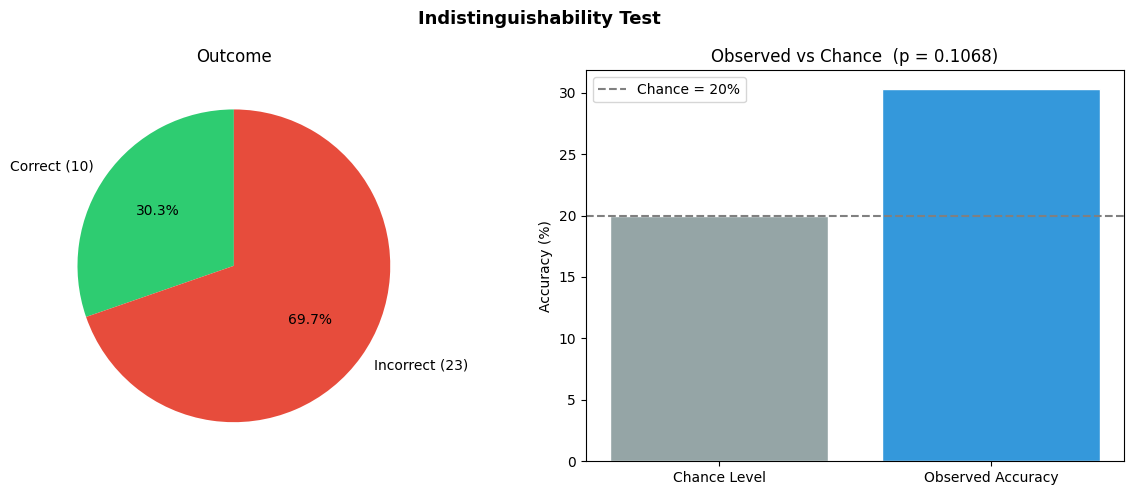

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Indistinguishability Test', fontsize=13, fontweight='bold')

axes[0].pie([n_correct, n_total - n_correct],
            labels=[f'Correct ({n_correct})', f'Incorrect ({n_total - n_correct})'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Outcome')

axes[1].bar(['Chance Level', 'Observed Accuracy'],
            [CHANCE_LEVEL * 100, obs_rate * 100],
            color=['#95a5a6', '#3498db'], edgecolor='white')
axes[1].axhline(CHANCE_LEVEL * 100, color='grey', linestyle='--', label=f'Chance = {CHANCE_LEVEL*100:.0f}%')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title(f'Observed vs Chance  (p = {result.pvalue:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('indistinguishability_test.png', bbox_inches='tight')
plt.show()

In [ ]:
ct_conf = pd.crosstab(df['confidence'], df['correct_password_chosen'])
ct_conf = ct_conf.reindex(confidence_order)
chi2_c, p_c, dof_c, _ = chi2_contingency(ct_conf)
rpb_c, p_rpb_c = pointbiserialr(df['confidence_ord'], df['correct_int'])

print("\n      CONFIDENCE vs. ACCURACY  ")
print(ct_conf)
print(f"Chi-square: chi2({dof_c}) = {chi2_c:.4f},  p = {p_c:.4f}")
print(f"Point-biserial r = {rpb_c:.4f},  p = {p_rpb_c:.4f}")


      CONFIDENCE vs. ACCURACY  
correct_password_chosen  False  True 
confidence                           
Not confident                3      0
Somewhat confident          10      5
Very confident              10      5
Chi-square: chi2(2) = 1.4348,  p = 0.4880
Point-biserial r = 0.1399,  p = 0.4375


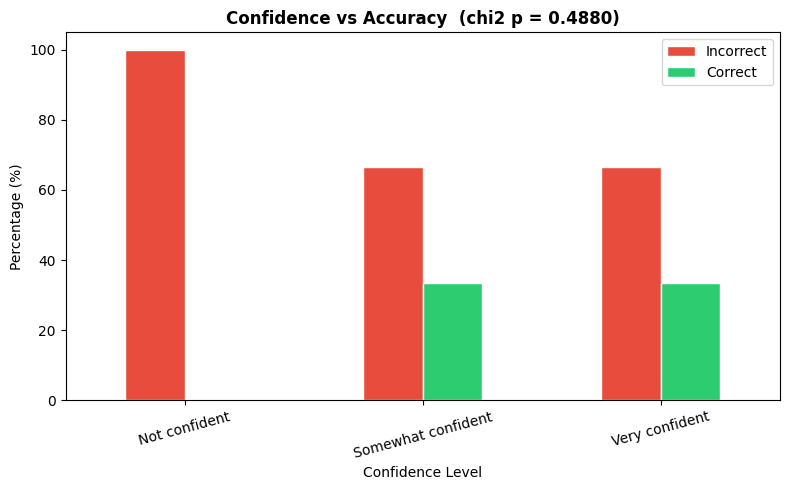

In [ ]:
ct_conf_pct = pd.crosstab(df['confidence'], df['correct_password_chosen'], normalize='index') * 100
ct_conf_pct = ct_conf_pct.reindex(confidence_order)
ct_conf_pct.plot(kind='bar', figsize=(8, 5), color=['#e74c3c', '#2ecc71'], edgecolor='white')
plt.title(f'Confidence vs Accuracy  (chi2 p = {p_c:.4f})', fontweight='bold')
plt.xlabel('Confidence Level')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.legend(['Incorrect', 'Correct'])
plt.tight_layout()
plt.savefig('confidence_vs_accuracy.png', bbox_inches='tight')
plt.show()

In [ ]:
ct_eng = pd.crosstab(df['english_level'], df['correct_password_chosen'])
ct_eng = ct_eng.reindex(english_order)
chi2_e, p_e, dof_e, _ = chi2_contingency(ct_eng)
rpb_e, p_rpb_e = pointbiserialr(df['english_ord'], df['correct_int'])

print("\n     ENGLISH PROFICIENCY vs. ACCURACY")
print(ct_eng)
print(f"Chi-square: chi2({dof_e}) = {chi2_e:.4f},  p = {p_e:.4f}")
print(f"Point-biserial r = {rpb_e:.4f},  p = {p_rpb_e:.4f}")


     ENGLISH PROFICIENCY vs. ACCURACY
correct_password_chosen  False  True 
english_level                        
Beginner                     2      0
Intermediate                12      7
Advanced                     9      3
Chi-square: chi2(2) = 1.4140,  p = 0.4931
Point-biserial r = -0.0035,  p = 0.9847


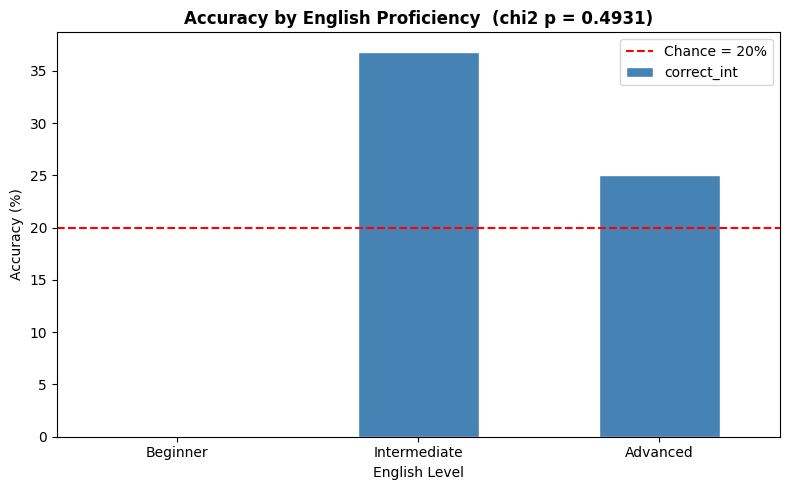

In [ ]:
acc_by_eng = df.groupby('english_level')['correct_int'].mean() * 100
acc_by_eng = acc_by_eng.reindex(english_order)
acc_by_eng.plot(kind='bar', figsize=(8, 5), color='steelblue', edgecolor='white')
plt.axhline(CHANCE_LEVEL * 100, color='red', linestyle='--', label=f'Chance = {CHANCE_LEVEL*100:.0f}%')
plt.title(f'Accuracy by English Proficiency  (chi2 p = {p_e:.4f})', fontweight='bold')
plt.xlabel('English Level')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('english_vs_accuracy.png', bbox_inches='tight')
plt.show()

In [ ]:
edu_order = ['No formal education', 'Basic education',
             'Senior secondary education', 'Tertiary education',
             'Postgraduate education']

ct_edu = pd.crosstab(df['education'], df['correct_password_chosen'])
ct_edu = ct_edu.reindex([e for e in edu_order if e in ct_edu.index])
chi2_edu, p_edu, dof_edu, _ = chi2_contingency(ct_edu)

print("\n     EDUCATION LEVEL vs. ACCURACY")
print(ct_edu)
print(f"Chi-square: chi2({dof_edu}) = {chi2_edu:.4f},  p = {p_edu:.4f}")


     EDUCATION LEVEL vs. ACCURACY
correct_password_chosen     False  True 
education                               
No formal education             1      0
Basic education                 0      1
Senior secondary education      3      2
Tertiary education             13      6
Postgraduate education          6      1
Chi-square: chi2(4) = 3.8223,  p = 0.4306


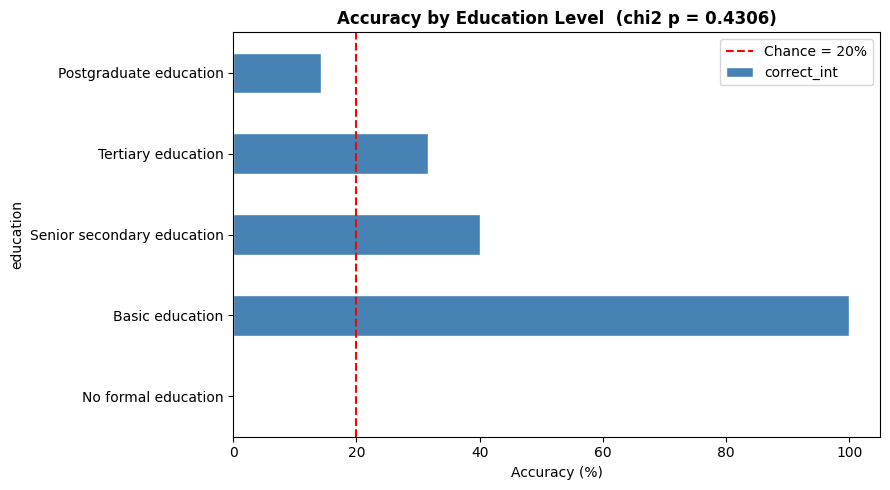

In [ ]:
acc_by_edu = df.groupby('education')['correct_int'].mean() * 100
acc_by_edu = acc_by_edu.reindex([e for e in edu_order if e in acc_by_edu.index])
acc_by_edu.plot(kind='barh', figsize=(9, 5), color='steelblue', edgecolor='white')
plt.axvline(CHANCE_LEVEL * 100, color='red', linestyle='--', label=f'Chance = {CHANCE_LEVEL*100:.0f}%')
plt.title(f'Accuracy by Education Level  (chi2 p = {p_edu:.4f})', fontweight='bold')
plt.xlabel('Accuracy (%)')
plt.legend()
plt.tight_layout()
plt.savefig('education_vs_accuracy.png', bbox_inches='tight')
plt.show()

**Summary Table**

In [ ]:
summary = pd.DataFrame([
    ['Indistinguishability', 'Binomial Test',      f'{n_correct}/{n_total} ({obs_rate*100:.1f}%)', f'{result.pvalue:.4f}', 'Fail to reject H0' if result.pvalue > 0.05 else 'Reject H0'],
    ['Confidence vs Accuracy',  'Chi-square',      f'chi2({dof_c})={chi2_c:.3f}',   f'{p_c:.4f}',   'Not significant' if p_c   > 0.05 else 'Significant'],
    ['Confidence vs Accuracy',  'Point-biserial',  f'r={rpb_c:.3f}',                f'{p_rpb_c:.4f}','Not significant' if p_rpb_c > 0.05 else 'Significant'],
    ['English vs Accuracy',     'Chi-square',      f'chi2({dof_e})={chi2_e:.3f}',   f'{p_e:.4f}',   'Not significant' if p_e   > 0.05 else 'Significant'],
    ['English vs Accuracy',     'Point-biserial',  f'r={rpb_e:.3f}',                f'{p_rpb_e:.4f}','Not significant' if p_rpb_e > 0.05 else 'Significant'],
    ['Education vs Accuracy',   'Chi-square',      f'chi2({dof_edu})={chi2_edu:.3f}',f'{p_edu:.4f}', 'Not significant' if p_edu > 0.05 else 'Significant'],
], columns=['Analysis', 'Test', 'Statistic', 'p-value', 'Result'])

print("\n      SUMMARY TABLE")
print(summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)


      SUMMARY TABLE
              Analysis           Test     Statistic p-value            Result
  Indistinguishability  Binomial Test 10/33 (30.3%)  0.1068 Fail to reject H0
Confidence vs Accuracy     Chi-square chi2(2)=1.435  0.4880   Not significant
Confidence vs Accuracy Point-biserial       r=0.140  0.4375   Not significant
   English vs Accuracy     Chi-square chi2(2)=1.414  0.4931   Not significant
   English vs Accuracy Point-biserial      r=-0.003  0.9847   Not significant
 Education vs Accuracy     Chi-square chi2(4)=3.822  0.4306   Not significant
